# IRSwap PCA Relative Value Butterfly Backtest

**Methodology:** Practitioner-grade PCA RV workflow
- **Stage 1:** Full-curve PCA scan across the forward surface -> Z-score rich/cheap map
- **Stage 2:** Trade-specific PCA on 3 selected tenors -> level+slope-neutral weights
- **Stage 3:** Ornstein-Uhlenbeck mean-reversion analytics (arbitragelab fork)
- **Stage 4:** Carry/roll-down integration + profitability filter

**Curve:** USD SOFR (ERIS EOD LIVE)  
**Structures:** Butterfly trades only  
**Modes:** spot | forward_stanchart | forward_cs

## 1. Setup & Config

In [1]:
%load_ext autoreload
%autoreload 2

import nest_asyncio
nest_asyncio.apply()

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large', 'figure.figsize': (14, 8),
          'axes.labelsize': 'x-large', 'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large', 'ytick.labelsize': 'x-large'}
pylab.rcParams.update(params)

import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import datetime, warnings
warnings.filterwarnings('ignore')
import pytz, pandas as pd, numpy as np

from BT.signals.irswap_pca_rv_scanner import (
    IRSwapPCARVConfig, scan_surface, zscore_snapshot,
    identify_candidates, analyze_candidates, build_signal_table,
    build_rate_queries, build_carry_roll_queries,
    reshape_rates_panel, reshape_carry_roll_panel,
)
from BT.signals.irswap_pca_rv_triggers import (
    IRSwapPCARVTrigger, run_irswap_pca_rv_backtest,
)

tz = pytz.timezone('America/New_York')
print('Imports OK')

Imports OK


In [2]:
# ══════════════════════════════════════════════════════════════
# CONFIGURATION — tweak parameters here for research
# ══════════════════════════════════════════════════════════════
MODE = 'forward_cs'  # 'spot' | 'forward_stanchart' | 'forward_cs'

config = IRSwapPCARVConfig(
    curve='USD-SOFR-1D',
    source='ERIS_EOD_LIVE-RL_BASIC',
    curve_input_mode=MODE,
    pca_window_days=260,
    zscore_lookback_days=260,
    pca_input='levels',
    min_zscore_belly=1.25,
    min_zscore_wing=0.3,
    max_adf_pvalue=0.15,
    min_half_life_days=3.0,
    max_half_life_days=120.0,
    auto_scan_fly=True,
    include_carry_roll=True,
    max_concurrent_positions=5,
    trade_belly_bpv=100_000.0,
)

# Date ranges
data_start = datetime.datetime(2022, 1, 1, 17, tzinfo=tz)
data_end = datetime.datetime(2026, 3, 27, 17, tzinfo=tz)
bt_start = datetime.datetime(2024, 6, 1, 17, tzinfo=tz)
bt_end = data_end

print(f'Mode: {config.curve_input_mode}')
print(f'PCA window: {config.pca_window_days}d, Z-score window: {config.zscore_lookback_days}d')
print(f'Min Z belly: {config.min_zscore_belly}, wing: {config.min_zscore_wing}')
print(f'ADF: {config.max_adf_pvalue}, HL: {config.min_half_life_days}-{config.max_half_life_days}d')

Mode: forward_cs
PCA window: 260d, Z-score window: 260d
Min Z belly: 1.25, wing: 0.3
ADF: 0.15, HL: 3.0-120.0d


## 2. Data Loading

In [3]:
from TB.TimeseriesBuilder import TimeseriesBuilder
from TB.IRSwapsTB import IRSwapsTB
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

curve_mdp = IRSwapsMDP(source=config.source)
ts_builder = TimeseriesBuilder()
queries = build_rate_queries(config)
router = {"IRS": IRSwapsTB(curve_mdp, show_tqdm=True)}

print(f"Fetching {len(queries)} rate queries...")
rates_df = ts_builder.get_timeseries(
    start=data_start,
    end=data_end,
    queries=queries,
    n_jobs=12,
    routers=router,
	ignore_cache_miss=True,
)
panels = reshape_rates_panel(rates_df, config)
print(f"Loaded panels for {len(panels)} forward starts")

any_panel = next(iter(panels.values()))
print(f"Date range: {any_panel.index[0]} to {any_panel.index[-1]}")
print(f"Panel shape: {any_panel.shape}")

# Carry/roll-down
carry_roll_panels = None
if config.include_carry_roll:
    try:
        cr_queries = build_carry_roll_queries(config)
        print(f"Fetching {len(cr_queries)} carry/roll queries...")
        cr_df = ts_builder.get_timeseries(
            start=data_start,
            end=data_end,
            queries=cr_queries,
            n_jobs=12,
            routers=router,
        )
        carry_roll_panels = reshape_carry_roll_panel(cr_df, config)
        print(f"Loaded carry/roll panels: {len(carry_roll_panels)}")
    except Exception as e:
        print(f"WARNING: Carry/roll failed: {e}")

Fetching 16 rate queries...


VECTOR PRICING USD-SOFR-1D IRS...:   0%|          | 0/1057 [00:00<?, ?it/s]                 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

LOADING USD-SOFR-1D raw curves...:   0%|          | 0/1057 [00:00<?, ?it/s]           

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded carry/roll panels: 1


## 3. Stage 1: PCA Surface Scan

In [11]:
print('Running Stage 1: Full-curve PCA surface scan...')
result = scan_surface(panels, config)

# Z-score snapshot
snap = zscore_snapshot(result)
if not snap.empty:
    def _color_zscore(val):
        if pd.isna(val): return ''
        if val > 1.5: return 'color: green; font-weight: bold'
        if val > 0: return 'color: green'
        if val < -1.5: return 'color: red; font-weight: bold'
        if val < 0: return 'color: red'
        return ''
    display(snap.style.map(_color_zscore).format('{:.2f}'))

Running Stage 1: Full-curve PCA surface scan...


,Spot
1Y,1.73
1Yx1Y,3.92
2Yx1Y,-1.21
3Yx1Y,-3.50
4Yx1Y,-1.46
5Yx1Y,-1.16
6Yx1Y,-1.58
7Yx1Y,-1.56
8Yx1Y,-1.11
9Yx1Y,-0.38


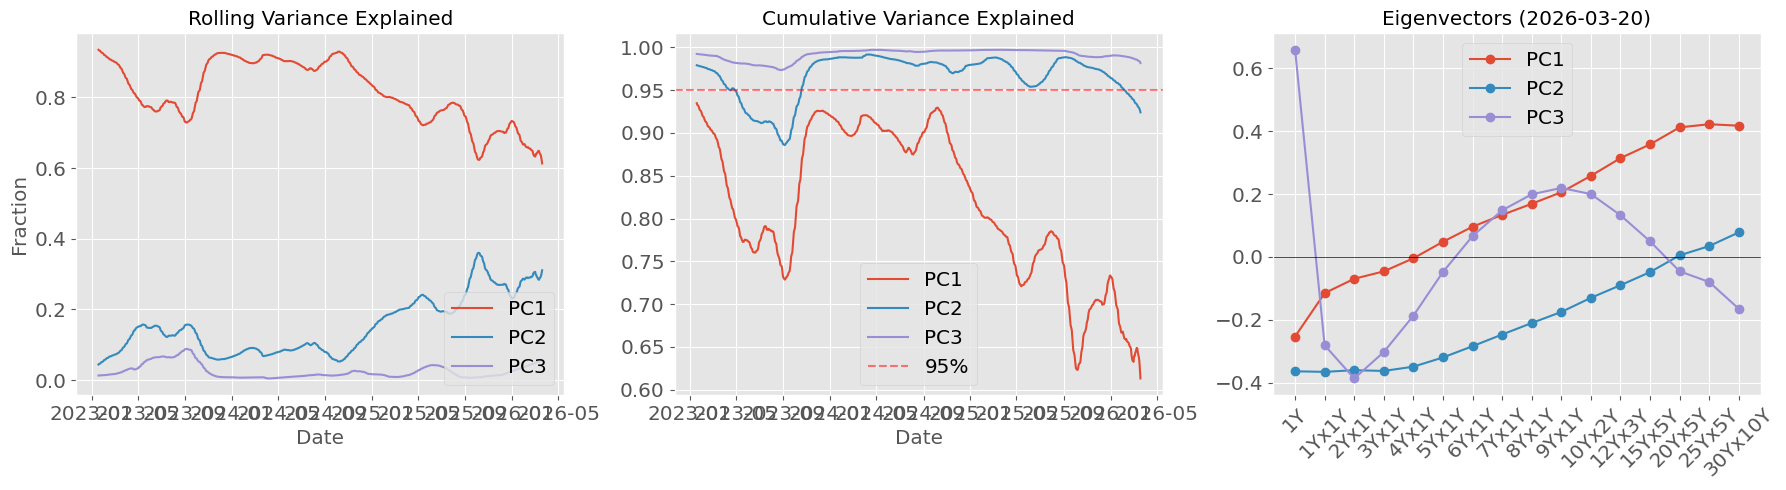

Avg total var explained: 99.2%


In [15]:
# Variance explained + eigenvector shape
fwd_key = None  # Spot curve
if fwd_key in result.variance_explained:
    ve = result.variance_explained[fwd_key].dropna()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Rolling variance explained
    ve.plot(ax=axes[0], title='Rolling Variance Explained')
    axes[0].set_ylabel('Fraction')
    axes[0].legend(loc='lower right')
    
    # Cumulative
    ve.cumsum(axis=1).plot(ax=axes[1], title='Cumulative Variance Explained')
    axes[1].axhline(0.95, color='red', ls='--', alpha=0.5, label='95%')
    axes[1].legend()
    
    # Latest eigenvector shape
    if result.loadings.get(fwd_key):
        last_date = sorted(result.loadings[fwd_key].keys())[-1]
        eigvecs = result.loadings[fwd_key][last_date]
        tenors = config.get_tenors_for_mode()
        for i in range(min(3, eigvecs.shape[1])):
            axes[2].plot(range(len(tenors)), eigvecs[:, i], 'o-', label=f'PC{i+1}')
        axes[2].set_xticks(range(len(tenors)))
        axes[2].set_xticklabels(tenors, rotation=45)
        axes[2].axhline(0, color='black', lw=0.5)
        axes[2].set_title(f'Eigenvectors ({last_date})')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    print(f'Avg total var explained: {ve.sum(axis=1).mean():.1%}')

## 4. Stage 2: Candidates

In [ ]:
candidates = identify_candidates(result, panels, config)
print(f'Found {len(candidates)} candidates at latest date')

if candidates:
    cand_df = pd.DataFrame([{
        'Fwd': c.forward_start or 'Spot',
        'Fly': f'{c.tenors[0]}/{c.tenors[1]}/{c.tenors[2]}',
        'Weights': f'{c.weights[0]:.2f} / 1.00 / {c.weights[2]:.2f}',
        'Dir': c.direction,
        'Z(belly)': f'{c.zscore_belly:.2f}',
        'Z(left)': f'{c.zscore_left:.2f}',
        'Z(right)': f'{c.zscore_right:.2f}',
    } for c in candidates])
    display(cand_df)

## 5. Stage 3: OU Analytics

In [ ]:
if candidates:
    trades = analyze_candidates(candidates, panels, config, carry_roll_panels)
    print(f'Analyzed {len(trades)} trades')
    passing = [t for t in trades if t.passes_filter]
    print(f'Passing: {len(passing)}')
    
    trade_df = pd.DataFrame([{
        'Fly': '/'.join(t.candidate.tenors),
        'Dir': t.candidate.direction[:3],
        'HL(d)': f'{t.half_life_days:.0f}',
        'ADF-p': f'{t.adf_pvalue:.3f}',
        'Z': f'{t.lifetime_zscore:.2f}',
        'Entry': f'{t.current_level*100:.1f}bp',
        'Target': f'{t.target_level*100:.1f}bp',
        'C+R': f'{t.carry_roll_bps:.2f}bp',
        'P/C': f'{t.profit_cost_ratio:.1f}',
        'Pass': t.passes_filter,
        'Reason': '; '.join(t.filter_reasons) if t.filter_reasons else '',
    } for t in trades])
    display(trade_df)

## 6. Signal Table + Backtest

In [ ]:
print(f'Building signal table ({bt_start.date()} to {bt_end.date()})...')
signal_table = build_signal_table(
    panels, config, carry_roll_panels,
    start_date=pd.Timestamp(bt_start), end_date=pd.Timestamp(bt_end),
)
total_sig = sum(len(v) for v in signal_table.values())
passing_sig = sum(sum(1 for t in v if t.passes_filter) for v in signal_table.values())
print(f'Signal table: {len(signal_table)} dates, {total_sig} total, {passing_sig} passing')

In [ ]:
bt_dates = pd.bdate_range(bt_start, bt_end, tz=tz)
bt_datetimes = [d.to_pydatetime() for d in bt_dates]

print(f'Running backtest: {bt_start.date()} to {bt_end.date()} ({len(bt_datetimes)} steps)')
bt = run_irswap_pca_rv_backtest(signal_table, config, curve_mdp, bt_datetimes)

## 7. Results

In [ ]:
mtm = pd.Series(bt.mtm_history).sort_index()
daily_pnl = mtm.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

mtm.plot(ax=axes[0], title=f'PCA RV Butterfly [{MODE}] - Cumulative MTM P&L ($)', lw=1.5)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_ylabel('P&L ($)')

dd = mtm - mtm.cummax()
dd.plot(ax=axes[1], title='Drawdown', color='red', lw=1)
axes[1].fill_between(dd.index, dd.values, 0, color='red', alpha=0.2)
axes[1].set_ylabel('Drawdown ($)')

plt.tight_layout()
plt.show()

sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0
print(f'Trades: {len(bt.portfolio.trades_log)} entries, {len(bt.portfolio.closed_positions_log)} closed')
print(f'Final MTM: ${mtm.iloc[-1]:,.0f} | Realized: ${bt.realized_pnl:,.0f}')
print(f'Sharpe: {sharpe:.2f} | Max DD: ${dd.min():,.0f} | Hit rate: {(daily_pnl>0).mean():.1%}')

In [ ]:
if bt.portfolio.closed_positions_log:
    log_df = pd.DataFrame([{
        'Opened': str(e['opened_at'])[:10],
        'Closed': str(e['closed_at'])[:10],
        'Days': f"{e['holding_period_days']:.0f}",
        'P&L': f"${e['realized_pnl']:,.0f}",
        'Reason': e.get('exit_meta', {}).get('reason', ''),
    } for e in bt.portfolio.closed_positions_log])
    print(f'Closed trade log ({len(log_df)} trades):')
    display(log_df)